In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv(r"C:\Users\Shiva kumar\OneDrive\Desktop\Project\data\youtube_channels_1M_clean.csv")
df.head()

,channel_id,channel_link,channel_name,subscriber_count,banner_link,description,keywords,avatar,country,total_views,total_videos,join_date,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week
0,UCUMHFa347GD8EIRaVVuxR8Q,/@TonettaClay,Tonetta Clay,781,https://yt3.googleusercontent.com/bj2C0MOj3SMi...,My name is Tonetta or Toni for short and I'm d...,NaN,https://yt3.googleusercontent.com/cUmKB4Zet1SX...,NaN,227567.0,1984.0,2015-12-08,10.866667,6.5,13.922963,1.50
1,UC28mqg7IlYWEhrZwHb72IQA,/@FoodnHappinessVeena,Food 'n' Happiness,0,NaN,"Hello viewers.\n I am Veena from Mangalore, Ka...","food n happiness, food and happiness, food, Fo...",https://yt3.googleusercontent.com/lY_u-8bLWNgA...,India,592961.0,158.0,2020-05-08,1448.066667,1510.0,869.364401,0.00
2,UCoLwWY9zQ7Jp8aDtYUszmYg,/@TimShieff,Tim Shieff,166000,https://yt3.googleusercontent.com/2KC8Lj8RF3uF...,The journey of rediscovery.\n\nhttps://rdscvr.com,"Tim, shieff, timothy, health, human, spiritual...",https://yt3.googleusercontent.com/-aNZLP23AnkX...,United Kingdom,27250763.0,372.0,2006-03-19,5456.933333,3430.0,4322.803149,0.00
3,UCAQOeJwsgBMC74-OjjcQcJA,/@JerryAndJulieMusic,Jerry & Julie Music,1090,https://yt3.googleusercontent.com/dI6Oq0iOhx-c...,Welcome to Jerry & Julie Music. We hope you w...,"jerryandjuliemusic, jerryspianobar, juliesguit...",https://yt3.googleusercontent.com/c41pe3_aA75h...,United States,339906.0,913.0,2010-03-27,75.966667,47.5,113.374448,4.00
4,UCOqwGhI1AmpWwxMYw9D_fqw,/@KichuandYugiMagizhakam,Kichu and Yugi Magizhakam,1160,https://yt3.googleusercontent.com/CXrATV8NKPRg...,Hi friends welcome to my channel...I'm Devi mo...,NaN,https://yt3.googleusercontent.com/FDA5pc1ZQ5jT...,NaN,288328.0,476.0,2023-12-21,85.700000,66.0,72.032007,1.25


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095242 entries, 0 to 1095241
Data columns (total 16 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   channel_id                   1095242 non-null  object 
 1   channel_link                 1095242 non-null  object 
 2   channel_name                 1095182 non-null  object 
 3   subscriber_count             1095242 non-null  int64  
 4   banner_link                  766877 non-null   object 
 5   description                  819743 non-null   object 
 6   keywords                     547203 non-null   object 
 7   avatar                       1095242 non-null  object 
 8   country                      620059 non-null   object 
 9   total_views                  1094490 non-null  float64
 10  total_videos                 1094985 non-null  float64
 11  join_date                    1095220 non-null  object 
 12  mean_views_last_30_videos    1059085 non-n

In [4]:
df.describe()

,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week
count,1.095242e+06,1.094490e+06,1.094985e+06,1.059085e+06,1.059085e+06,1.059085e+06,1.059085e+06
mean,6.718270e+04,2.558005e+07,4.139291e+02,4.173914e+04,1.937563e+04,6.503651e+04,6.252839e-01
std,8.592589e+05,5.176393e+08,3.910517e+03,1.322847e+06,8.900375e+05,1.908503e+06,1.535874e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.300000e+01,8.288000e+03,2.300000e+01,8.742857e+01,4.000000e+01,7.678400e+01,0.000000e+00
50%,3.730000e+02,8.386200e+04,8.400000e+01,4.253333e+02,1.455000e+02,5.438977e+02,0.000000e+00
75%,2.900000e+03,6.678882e+05,2.670000e+02,2.587567e+03,7.525000e+02,4.089039e+03,5.000000e-01
max,2.440000e+08,1.788442e+11,1.248360e+06,6.889384e+08,6.712840e+08,1.069565e+09,7.500000e+00


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum().sort_values(ascending=False)

keywords                       548039
country                        475183
banner_link                    328365
description                    275499
mean_views_last_30_videos       36157
median_views_last_30_videos     36157
std_views_last_30_videos        36157
videos_per_week                 36157
total_views                       752
total_videos                      257
channel_name                       60
join_date                          22
avatar                              0
channel_id                          0
channel_link                        0
subscriber_count                    0
dtype: int64

In [7]:
#Droping useless columns
df.drop(columns=[
'keywords',
'country',
'banner_link',
'description',
'avatar',
'channel_id',
'channel_link'
], inplace=True)

In [8]:
#handling missing numerical values
num_cols = [
'mean_views_last_30_videos',
'median_views_last_30_videos',
'std_views_last_30_videos',
'videos_per_week',
'total_views',
'total_videos'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
#Handling join_date
df['join_date'] = pd.to_datetime(df['join_date'])

df['channel_age'] = 2025 - df['join_date'].dt.year

In [10]:
df.drop(columns=['join_date'], inplace=True)

In [11]:
#Handling missing channel names
df.dropna(subset=['channel_name'], inplace=True)

In [12]:
df.isnull().sum()

channel_name                    0
subscriber_count                0
total_views                     0
total_videos                    0
mean_views_last_30_videos       0
median_views_last_30_videos     0
std_views_last_30_videos        0
videos_per_week                 0
channel_age                    22
dtype: int64

In [13]:
df['channel_age'] = df['channel_age'].fillna(df['channel_age'].median())

In [14]:
df.isnull().sum()

channel_name                   0
subscriber_count               0
total_views                    0
total_videos                   0
mean_views_last_30_videos      0
median_views_last_30_videos    0
std_views_last_30_videos       0
videos_per_week                0
channel_age                    0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095182 entries, 0 to 1095241
Data columns (total 9 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   channel_name                 1095182 non-null  object 
 1   subscriber_count             1095182 non-null  int64  
 2   total_views                  1095182 non-null  float64
 3   total_videos                 1095182 non-null  float64
 4   mean_views_last_30_videos    1095182 non-null  float64
 5   median_views_last_30_videos  1095182 non-null  float64
 6   std_views_last_30_videos     1095182 non-null  float64
 7   videos_per_week              1095182 non-null  float64
 8   channel_age                  1095182 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 83.6+ MB


In [16]:
df.shape

(1095182, 9)

In [17]:
df.describe()

,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week,channel_age
count,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06
mean,6.718622e+04,2.556390e+07,4.138509e+02,4.037727e+04,1.874175e+04,6.291026e+04,6.046292e-01,8.665234e+00
std,8.592823e+05,5.174761e+08,3.910162e+03,1.300884e+06,8.752536e+05,1.876822e+06,1.514410e+00,4.724011e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,3.300000e+01,8.306000e+03,2.300000e+01,9.260000e+01,4.200000e+01,8.259555e+01,0.000000e+00,5.000000e+00
50%,3.730000e+02,8.386200e+04,8.400000e+01,4.253333e+02,1.455000e+02,5.438977e+02,0.000000e+00,8.000000e+00
75%,2.900000e+03,6.666632e+05,2.670000e+02,2.400117e+03,6.980000e+02,3.779276e+03,2.500000e-01,1.200000e+01
max,2.440000e+08,1.788442e+11,1.248360e+06,6.889384e+08,6.712840e+08,1.069565e+09,7.500000e+00,2.000000e+01


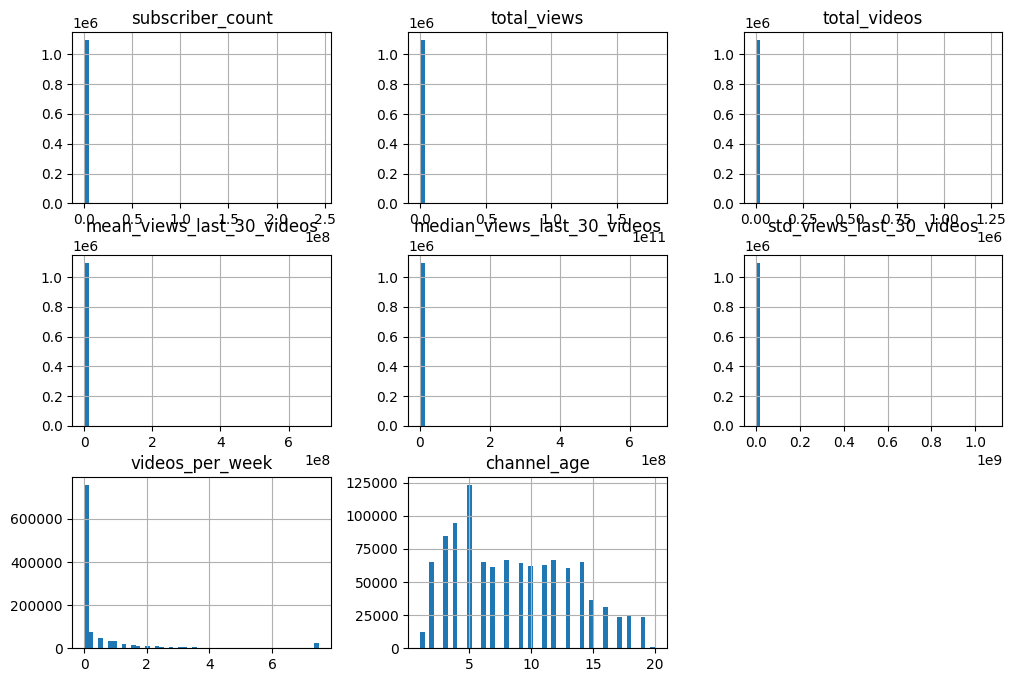

In [18]:
df.hist(figsize=(12,8),bins=50)
plt.show()

In [19]:
df['log_subscribers']=np.log1p(df['subscriber_count'])
df['log_views']=np.log1p(df['total_views'])

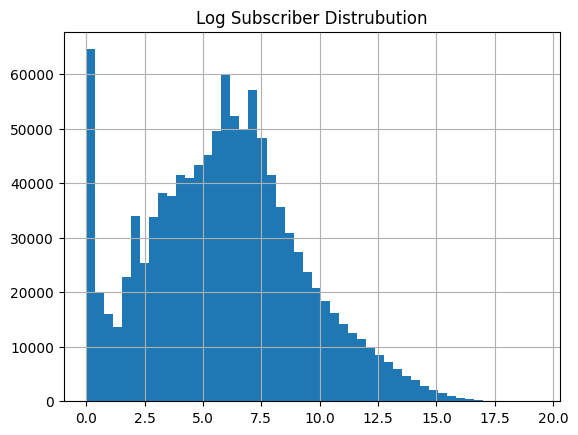

In [20]:
df['log_subscribers'].hist(bins=50)
plt.title("Log Subscriber Distrubution")
plt.show()

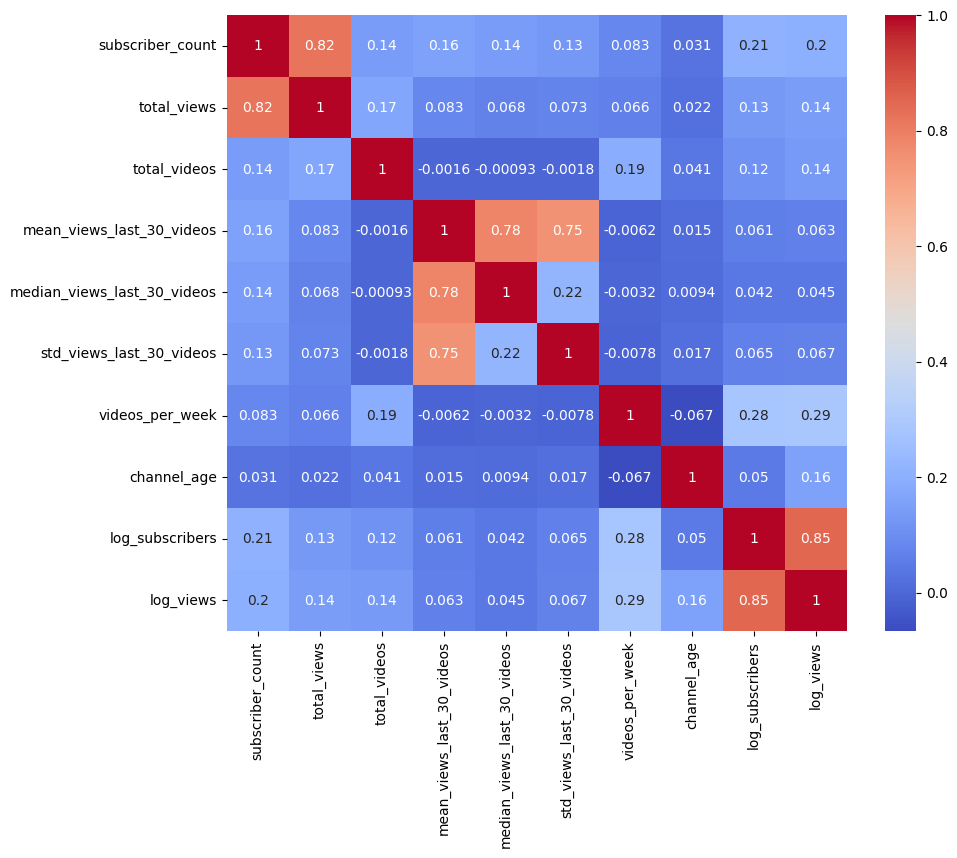

In [21]:
#Correlation Analysis
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True,cmap='coolwarm')
plt.show()

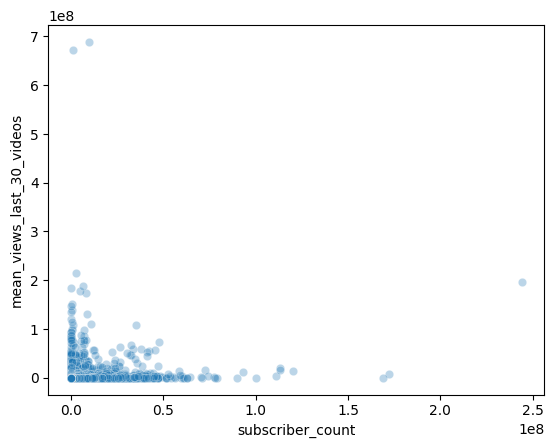

In [22]:
#Relationship between importent features
sns.scatterplot(
    x='subscriber_count',
    y='mean_views_last_30_videos',
    data=df,
    alpha=0.3)
plt.show()
    

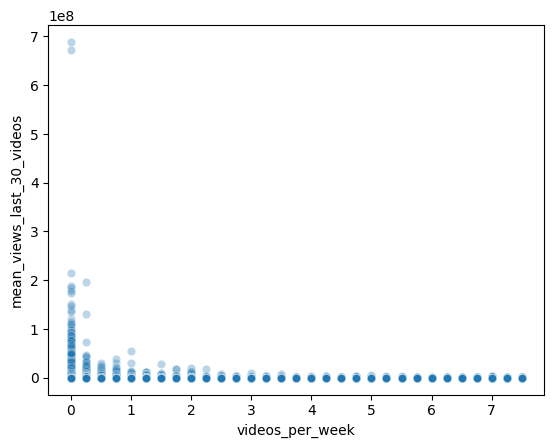

In [23]:
sns.scatterplot(
    x='videos_per_week',
    y='mean_views_last_30_videos',
    data=df,
    alpha=0.3)
plt.show()

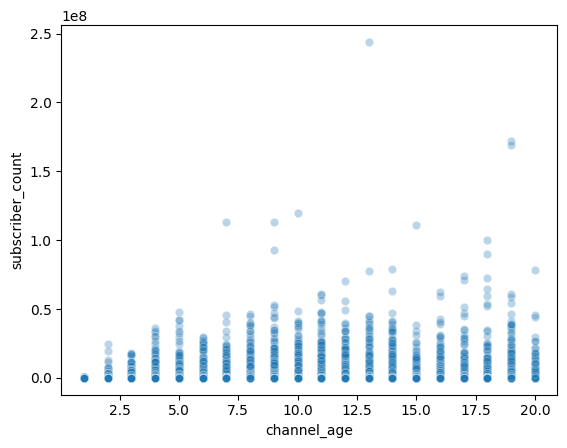

In [24]:
sns.scatterplot(
    x='channel_age',
    y='subscriber_count',
    data=df,
    alpha=0.3)
plt.show()

In [25]:
df.nlargest(15,'subscriber_count')

,channel_name,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week,channel_age,log_subscribers,log_views
1086644,MrBeast,244000000,4.457287e+10,780.0,1.971791e+08,178387547.0,6.014584e+07,0.25,13.0,19.312679,24.520391
1015791,Cocomelon - Nursery Rhymes,172000000,1.788442e+11,1103.0,7.234832e+06,5990773.5,6.603092e+06,2.00,19.0,18.963005,25.909781
1032344,SET India,169000000,1.600517e+11,131706.0,8.835636e+03,5763.0,6.388415e+03,2.75,19.0,18.945409,25.798763
1063132,✿ Kids Diana Show,120000000,1.010369e+11,1171.0,1.374279e+07,10483458.5,1.283455e+07,2.00,10.0,18.603002,25.338751
1016860,Vlad and Niki,113000000,8.695447e+10,672.0,2.051446e+07,13512903.0,1.852569e+07,2.00,7.0,18.542898,25.188650
1053013,Like Nastya,113000000,9.841474e+10,871.0,1.643684e+07,10265658.0,1.496219e+07,0.75,9.0,18.542898,25.312456
1038832,PewDiePie,111000000,2.925018e+10,4755.0,3.455557e+06,3012912.0,2.194216e+06,0.75,15.0,18.525041,24.099151
1022968,WWE,100000000,8.229546e+10,74434.0,3.007688e+05,150439.0,5.273718e+05,7.25,18.0,18.420681,25.133582
535780,BLACKPINK,93100000,3.213887e+10,592.0,1.239394e+07,2819826.5,2.791775e+07,0.00,9.0,18.349185,24.193332
18705,Sony SAB,90000000,1.115020e+11,81164.0,1.042640e+04,4775.0,1.274201e+04,2.50,18.0,18.315320,25.437308


In [27]:
# df = df.drop('view_per_subscriber', axis=1)

In [29]:
df['subscriber_count'].eq(0).sum()

np.int64(64541)

In [30]:
df['mean_views_last_30_videos'].isnull().sum()

np.int64(0)

In [31]:
#replacing null values in subsciber count
df['subscriber_count']=df['subscriber_count'].replace(0,1)

In [32]:
df['subscriber_count'].eq(0).sum()

np.int64(0)

In [33]:
df['views_per_subscriber']=(df['mean_views_last_30_videos']/df['subscriber_count'])

In [34]:
df.head()

,channel_name,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week,channel_age,log_subscribers,log_views,views_per_subscriber
0,Tonetta Clay,781,227567.0,1984.0,10.866667,6.5,13.922963,1.50,10.0,6.661855,12.335204,0.013914
1,Food 'n' Happiness,1,592961.0,158.0,1448.066667,1510.0,869.364401,0.00,5.0,0.000000,13.292886,1448.066667
2,Tim Shieff,166000,27250763.0,372.0,5456.933333,3430.0,4322.803149,0.00,19.0,12.019749,17.120592,0.032873
3,Jerry & Julie Music,1090,339906.0,913.0,75.966667,47.5,113.374448,4.00,15.0,6.994850,12.736427,0.069694
4,Kichu and Yugi Magizhakam,1160,288328.0,476.0,85.700000,66.0,72.032007,1.25,2.0,7.057037,12.571857,0.073879


In [35]:
df['views_per_subscriber'].isnull().sum()

np.int64(0)

In [36]:
#Removing infinite values
df['views_per_subscriber']=df['views_per_subscriber'].replace([np.inf,-np.inf],np.nan)

In [37]:
df['views_per_subscriber']=df['views_per_subscriber'].fillna(df['views_per_subscriber'].median())

In [38]:
df['views_per_subscriber']=df['views_per_subscriber'].clip(upper=df['views_per_subscriber'].quantile(0.99))

In [39]:
df['views_per_subscriber'].isnull().sum()

np.int64(0)

In [40]:
df.describe()

,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week,channel_age,log_subscribers,log_views,views_per_subscriber
count,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06,1.095182e+06
mean,6.718628e+04,2.556390e+07,4.138509e+02,4.037727e+04,1.874175e+04,6.291026e+04,6.046292e-01,8.665234e+00,5.908334e+00,1.129167e+01,6.124107e+01
std,8.592823e+05,5.174761e+08,3.910162e+03,1.300884e+06,8.752536e+05,1.876822e+06,1.514410e+00,4.724011e+00,3.315820e+00,3.465675e+00,2.973216e+02
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,6.931472e-01,0.000000e+00
25%,3.300000e+01,8.306000e+03,2.300000e+01,9.260000e+01,4.200000e+01,8.259555e+01,0.000000e+00,5.000000e+00,3.526361e+00,9.024854e+00,2.146582e-01
50%,3.730000e+02,8.386200e+04,8.400000e+01,4.253333e+02,1.455000e+02,5.438977e+02,0.000000e+00,8.000000e+00,5.924256e+00,1.133694e+01,1.250373e+00
75%,2.900000e+03,6.666632e+05,2.670000e+02,2.400117e+03,6.980000e+02,3.779276e+03,2.500000e-01,1.200000e+01,7.972811e+00,1.341004e+01,8.375000e+00
max,2.440000e+08,1.788442e+11,1.248360e+06,6.889384e+08,6.712840e+08,1.069565e+09,7.500000e+00,2.000000e+01,1.931268e+01,2.590978e+01,2.531006e+03


In [41]:
df['views_per_subscriber'].describe()

count    1.095182e+06
mean     6.124107e+01
std      2.973216e+02
min      0.000000e+00
25%      2.146582e-01
50%      1.250373e+00
75%      8.375000e+00
max      2.531006e+03
Name: views_per_subscriber, dtype: float64

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095182 entries, 0 to 1095241
Data columns (total 12 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   channel_name                 1095182 non-null  object 
 1   subscriber_count             1095182 non-null  int64  
 2   total_views                  1095182 non-null  float64
 3   total_videos                 1095182 non-null  float64
 4   mean_views_last_30_videos    1095182 non-null  float64
 5   median_views_last_30_videos  1095182 non-null  float64
 6   std_views_last_30_videos     1095182 non-null  float64
 7   videos_per_week              1095182 non-null  float64
 8   channel_age                  1095182 non-null  float64
 9   log_subscribers              1095182 non-null  float64
 10  log_views                    1095182 non-null  float64
 11  views_per_subscriber         1095182 non-null  float64
dtypes: float64(10), int64(1), object(1)
memory usag

In [43]:
growth_threshold=df['views_per_subscriber'].median()
df['growth_label']=(df['views_per_subscriber']>growth_threshold).astype(int)

In [44]:
df.head()

,channel_name,subscriber_count,total_views,total_videos,mean_views_last_30_videos,median_views_last_30_videos,std_views_last_30_videos,videos_per_week,channel_age,log_subscribers,log_views,views_per_subscriber,growth_label
0,Tonetta Clay,781,227567.0,1984.0,10.866667,6.5,13.922963,1.50,10.0,6.661855,12.335204,0.013914,0
1,Food 'n' Happiness,1,592961.0,158.0,1448.066667,1510.0,869.364401,0.00,5.0,0.000000,13.292886,1448.066667,1
2,Tim Shieff,166000,27250763.0,372.0,5456.933333,3430.0,4322.803149,0.00,19.0,12.019749,17.120592,0.032873,0
3,Jerry & Julie Music,1090,339906.0,913.0,75.966667,47.5,113.374448,4.00,15.0,6.994850,12.736427,0.069694,0
4,Kichu and Yugi Magizhakam,1160,288328.0,476.0,85.700000,66.0,72.032007,1.25,2.0,7.057037,12.571857,0.073879,0


In [45]:
df['growth_label'].value_counts()

growth_label
0    547591
1    547591
Name: count, dtype: int64

In [46]:
df=df.drop(columns=['channel_name'])

In [56]:
# X=df.drop(columns=['growth_label'])
# y=df['growth_label']
X = df.drop(columns=["growth_label", "views_per_subscriber"])
y = df["growth_label"]

In [57]:
print(X.shape,y.shape)

(1095182, 10) (1095182,)


In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [59]:
print(X_train.shape,X_test.shape)

(876145, 10) (219037, 10)


In [60]:
#Feature scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [61]:
#Logisitic Regression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
#DecisionTreeclassifier
tree_model=DecisionTreeClassifier(max_depth=8,random_state=42)
tree_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [63]:
#Logistic regression Accuracy
log_train_pred=log_model.predict(X_train_scaled)
log_test_pred=log_model.predict(X_test_scaled)


print("Logistic Train Accuracy:",accuracy_score(y_train,log_train_pred))
print("Logistic Test Accuracy:",accuracy_score(y_test,log_test_pred))

Logistic Train Accuracy: 0.8512289632423857
Logistic Test Accuracy: 0.8499248985331246


In [64]:
tree_train_pred=tree_model.predict(X_train)
tree_test_pred=tree_model.predict(X_test)

print("Decision Tree Train Accuracy:",accuracy_score(y_train,tree_train_pred))
print("Decision Tree Test Accuracy:",accuracy_score(y_test,tree_test_pred))

Decision Tree Train Accuracy: 0.9569648859492436
Decision Tree Test Accuracy: 0.9555097997142036


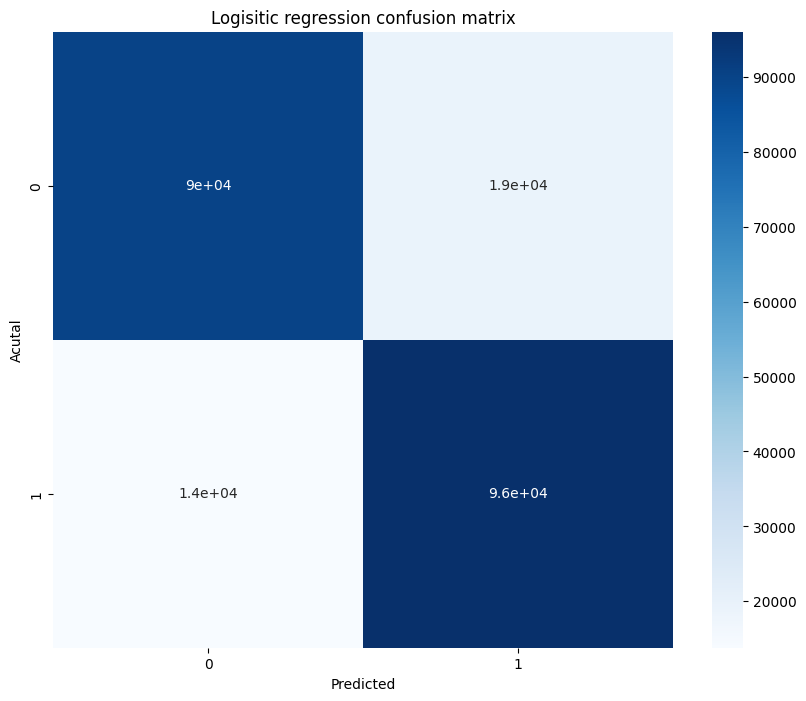

In [66]:
cm_log=confusion_matrix(y_test,log_test_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_log,annot=True,cmap='Blues')
plt.title("Logisitic regression confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()

In [67]:
print(classification_report(y_test,log_test_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85    109211
           1       0.83      0.87      0.85    109826

    accuracy                           0.85    219037
   macro avg       0.85      0.85      0.85    219037
weighted avg       0.85      0.85      0.85    219037



In [69]:
#Feature importences
feature_importence=pd.DataFrame({
    "feature":X.columns,
    "importences":tree_model.feature_importances_})

feature_importence=feature_importence.sort_values(by="importences",ascending=False)
print(feature_importence)

                       feature  importences
2                 total_videos     0.481089
0             subscriber_count     0.186016
3    mean_views_last_30_videos     0.147576
5     std_views_last_30_videos     0.094752
8              log_subscribers     0.090566
1                  total_views     0.000000
4  median_views_last_30_videos     0.000000
6              videos_per_week     0.000000
7                  channel_age     0.000000
9                    log_views     0.000000


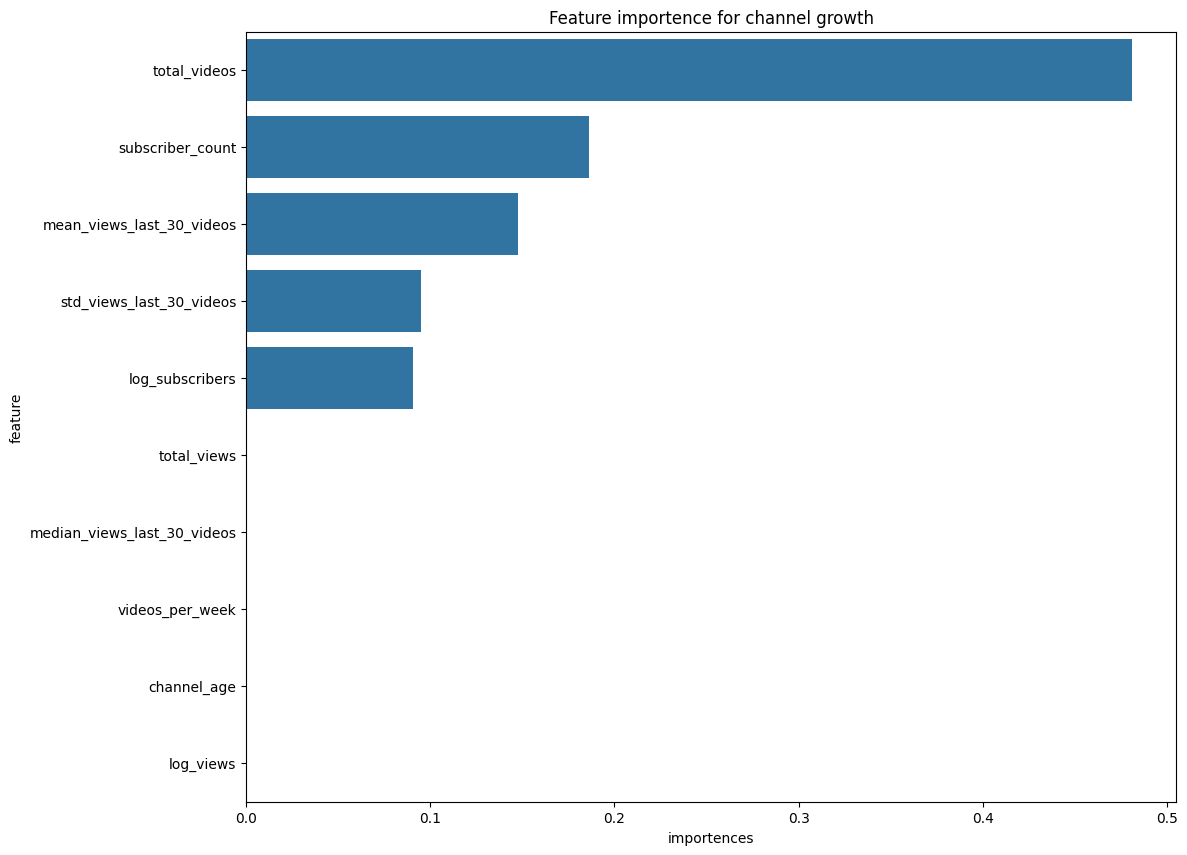

In [71]:
plt.figure(figsize=(12,10))
sns.barplot(x='importences',y='feature',data=feature_importence)
plt.title("Feature importence for channel growth")
plt.show()

In [72]:
#Growth quandrant analysis
df["views_per_subscriber"] = (
    df["mean_views_last_30_videos"] /
    df["subscriber_count"]
)

df["views_per_subscriber"] = df["views_per_subscriber"].replace([np.inf, -np.inf], np.nan)

df["views_per_subscriber"] = df["views_per_subscriber"].fillna(0)

In [76]:
df["views_per_subscriber_plot"] = df["views_per_subscriber"].clip(
    upper=df["views_per_subscriber"].quantile(0.99)
)

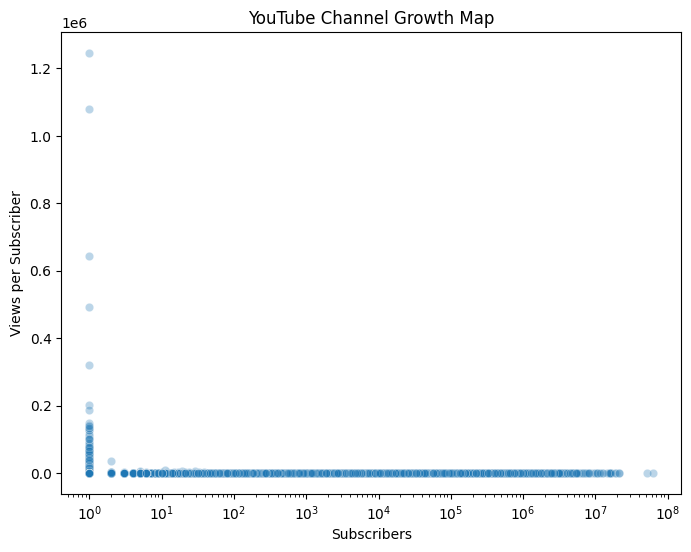

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="subscriber_count",
    y="views_per_subscriber",
    data=df.sample(20000),   # sampling for speed
    alpha=0.3
)

plt.xscale("log")

plt.title("YouTube Channel Growth Map")
plt.xlabel("Subscribers")
plt.ylabel("Views per Subscriber")

plt.show()

In [79]:
sub_median = df["subscriber_count"].median()
view_median = df["views_per_subscriber"].median()

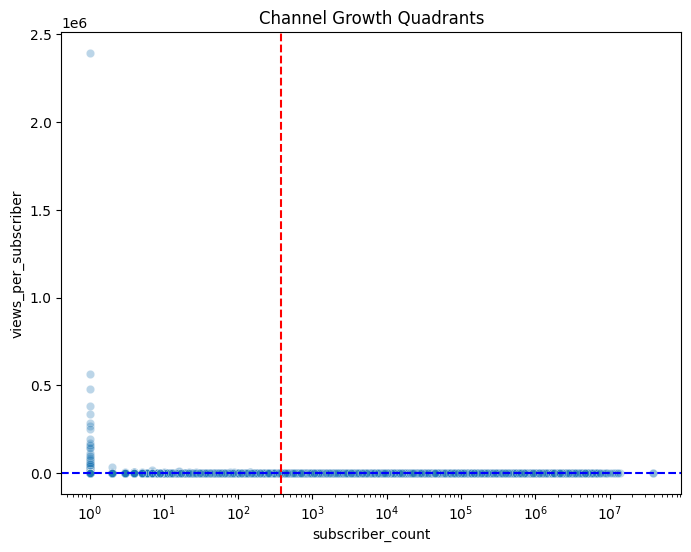

In [75]:
plt.figure(figsize=(8,6))

sample_df = df.sample(20000)

sns.scatterplot(
    x="subscriber_count",
    y="views_per_subscriber",
    data=sample_df,
    alpha=0.3
)

plt.axvline(sub_median, color="red", linestyle="--")
plt.axhline(view_median, color="blue", linestyle="--")

plt.xscale("log")

plt.title("Channel Growth Quadrants")

plt.show()

In [84]:
# #growth Score System
# df["growth_score"] = (
#     0.5 * df["views_per_subscriber"] +
#     0.2 * df["videos_per_week"] +
#     0.3 * df["mean_views_last_30_videos"]
# )

In [85]:
# df["growth_score"] = df["growth_score"] * 100


In [86]:
# df['growth_score'].describe()

In [87]:
# df[["channel_name","growth_score"]].sort_values(
#     by="growth_score",
#     ascending=False
# ).head(10)

In [88]:
df["growth_category"] = pd.cut(
    df["growth_score"],
    bins=[0,25,50,75,100],
    labels=["Declining","Slow","Stable","Rising"]
)

In [89]:
df["growth_category"].value_counts()

growth_category
Rising       2371
Stable       1750
Slow         1439
Declining     823
Name: count, dtype: int64

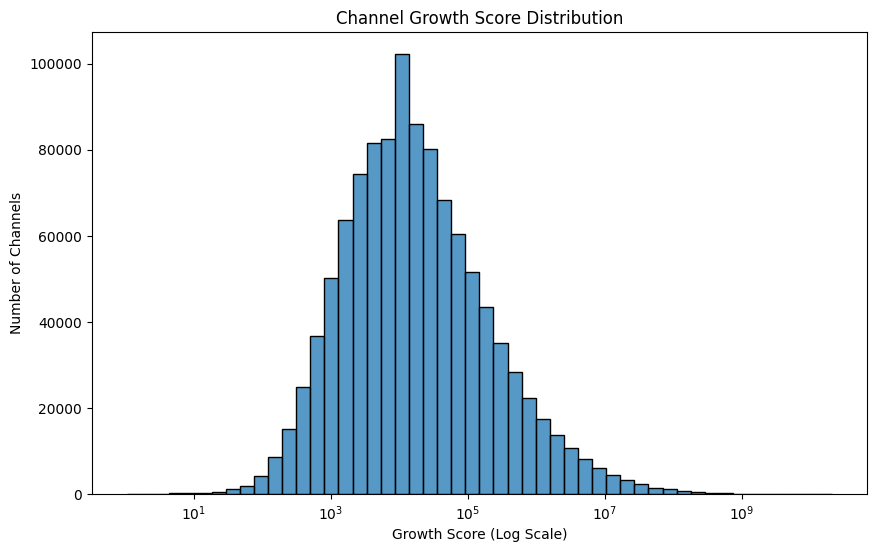

In [91]:
plt.figure(figsize=(10,6))
sns.histplot(df['growth_score'], bins=50, log_scale=True)
plt.title("Channel Growth Score Distribution")
plt.xlabel("Growth Score (Log Scale)")
plt.ylabel("Number of Channels")
plt.show()